In [10]:
import numpy as np
import matplotlib.pyplot as plt

# House size in sq ft
X = np.array([
    450, 600, 750, 800, 900, 1000, 1100, 1200, 1250, 1400,
    1500, 1600, 1750, 1800, 1900, 2000, 2200, 2400, 2600, 3000
])

# Price in lakhs (₹)
y = np.array([
    32, 45, 50, 65, 60, 78, 72, 95, 88, 102,
    115, 125, 130, 145, 138, 165, 175, 195, 220, 270
])

learning_rate = 0.01
epochs = 5000

X_scaled = X/1000
lambda_reg = 1

n = len(X_scaled)

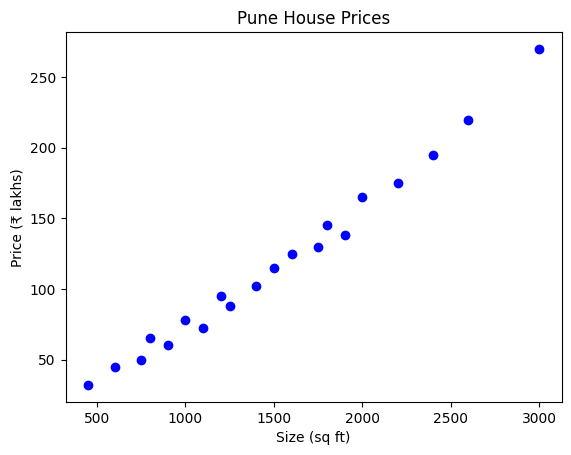

In [11]:
plt.scatter(X, y, color='blue', label='Actual data')
plt.xlabel('Size (sq ft)')
plt.ylabel('Price (₹ lakhs)')
plt.title('Pune House Prices')
plt.show()

In [12]:
w_linear = 0.0
b_linear = 0.0

for epoch in range(epochs):
    y_pred = w_linear * X_scaled + b_linear
    error = y_pred - y
    
    dw = (2/n) * np.sum(error * X_scaled)
    db = (2/n) * np.sum(error)
    
    w_linear -= learning_rate * dw
    b_linear -= learning_rate * db

print(f"Linear:  w = {w_linear:.4f}, b = {b_linear:.4f}")

Linear:  w = 89.5047, b = -16.9021


In [14]:
w_ridge = 0.0
b_ridge = 0.0

for epoch in range(epochs):
        y_pred = w_ridge * X_scaled + b_ridge
    
        error = y_pred - y
    
        dw_ridge = (2/n) * np.sum(error * X_scaled) + 2 * lambda_reg * w_ridge
        db_ridge = (2/n) * np.sum(error)
    
        w_ridge = w_ridge - learning_rate * dw_ridge
        b_ridge = b_ridge - learning_rate * db_ridge
    
print(f"Ridge:   w = {w_ridge:.4f}, b = {b_ridge:.4f}")

Ridge:   w = 28.2589, b = 75.5791


In [15]:
# Linear Regression: Use it to predict
param = 2550
prediction = w_linear * param + b_linear
print(f"Linear Regression:: The house of {param} sqft costs approximately {prediction:.2f}")

# Ridge Regression:Use it to predict
param = 2550
prediction = w_ridge * param + b_ridge
print(f"Ridge Regression:: The house of {param} sqft costs approximately {prediction:.2f}")

Linear Regression:: The house of 2550 sqft costs approximately 228220.04
Ridge Regression:: The house of 2550 sqft costs approximately 72135.68


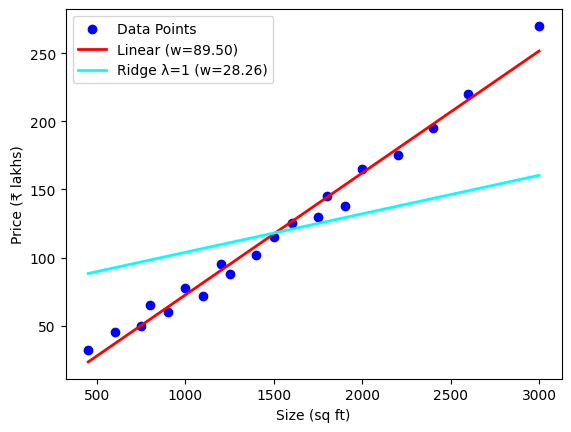

In [16]:
plt.scatter(X, y, color='blue', label='Data Points')

y_linear = w_linear * X_scaled + b_linear
y_ridge = w_ridge * X_scaled + b_ridge

plt.plot(X, y_linear, color='red', linewidth=2, label=f'Linear (w={w_linear:.2f})')
plt.plot(X, y_ridge, color='cyan', linewidth=2, label=f'Ridge λ={lambda_reg} (w={w_ridge:.2f})')

plt.xlabel('Size (sq ft)')
plt.ylabel('Price (₹ lakhs)')
plt.legend()
plt.show()

In [17]:
print("\n=== Ridge: How weight shrinks with λ ===")
for lam in [0, 0.001, 0.01, 0.1, 1, 10, 100]:
    w_test, b_test = 0.0, 0.0
    for epoch in range(5000):
        y_pred = w_test * X_scaled + b_test
        error = y_pred - y
        dw = (2/n) * np.sum(error * X_scaled) + 2 * lam * w_test
        db = (2/n) * np.sum(error)
        w_test -= 0.01 * dw
        b_test -= 0.01 * db
    print(f"  λ={lam:>8}: w = {w_test:.4f}, b = {b_test:.4f}")


=== Ridge: How weight shrinks with λ ===
  λ=       0: w = 89.5047, b = -16.9021
  λ=   0.001: w = 89.3111, b = -16.6098
  λ=    0.01: w = 87.6060, b = -14.0351
  λ=     0.1: w = 73.5616, b = 7.1719
  λ=       1: w = 28.2589, b = 75.5791
  λ=      10: w = 3.9476, b = 112.2891
  λ=     100: w = -1473369301370442210467374258107110160670616022144630855327428219077861988025442971724022973298787741477563514168016896.0000, b = -21862247011345805488133591953181533807886091780971010013593389509244934278983764665559196083659509758742220303761408.0000
